#Implementacion de KNN
###El algoritmo de k-nearest neighbors (KNN) es un clasificador de aprendizaje supervisado no paramétrico, que emplea la proximidad para realizar clasificaciones o predicciones sobre la agrupación de un punto de datos individual.

####La complejidad temporal de prediccion del modelo se expresa como
##$$O(n \cdot d)$$
####Donde n es el numero de muestras, y d es el numero de dimensiones o caracteristicas de esta



####Codigo Adaptado de:
https://machinelearningmastery.com/tutorial-to-implement-k-nearest-neighbors-in-python-from-scratch/?utm_source=


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt
from collections import Counter

from random import seed
from random import randrange

import time

In [45]:
url = 'https://raw.githubusercontent.com/angelemmavelasco/JAPI/refs/heads/main/data/sales.csv'
df = pd.read_csv(url)
df.head()

,id,doc_id,sale_date,total_cost,net_price,gross_price,profit,quantity,customer_id,product_id,product_class_id,route_id,warehouse_id
0,654255,mx 51841,2025-08-04,5681.140252,7500.0000,7500.0000,1818.859748,8,20889,NLAM40,nat,96.0,cdmx
1,654256,mx 51841,2025-08-04,353.420434,469.8276,469.8276,116.407166,2,20889,NLAM6,nat,96.0,cdmx
2,654257,mx 51841,2025-08-04,1240.348891,1646.5517,1646.5517,406.202809,2,20889,PREM40,dmd,96.0,cdmx
3,654258,mx 51841,2025-08-04,649.051367,862.0690,862.0690,213.017633,5,20889,PREM6,dmd,96.0,cdmx
4,654259,mx 51841,2025-08-04,424.642649,556.0345,556.0345,131.391851,2,20889,PSC5,tow,96.0,cdmx


##Implementacion manual del algoritmo

###Para una predicción individual, KNN manual tiene complejidad O(n·d), donde n es el número de ejemplos de entrenamiento y d el número de características.

###Como en la evaluación se predicen múltiples instancias usando validación cruzada, el costo total se aproxima a O(n_test · n_train · d). Si train y test crecen proporcionalmente, el comportamiento empírico puede aproximarse a O(n²·d).

In [46]:
df['sale_date'] = pd.to_datetime(
    df['sale_date']
)

reference_date = df['sale_date'].max()

rfm = df.groupby('customer_id').agg({

    'sale_date': lambda x:
        (reference_date - x.max()).days,

    'doc_id': 'nunique',

    'net_price': 'sum'

}).reset_index()

rfm.columns = [

    'customer_id',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm['target'] = (

    (rfm['Recency'] <= 100)

    &

    (rfm['Frequency'] >= 30)

    &

    (rfm['Monetary'] >= 100000)

).astype(int)

features = [
    'Recency',
    'Frequency',
    'Monetary'
]

dataset = rfm[
    features + ['target']
].values.tolist()

In [47]:
def dataset_minmax(dataset):

    minmax = list()

    for i in range(len(dataset[0]) - 1):

        col_values = [row[i] for row in dataset]

        value_min = min(col_values)
        value_max = max(col_values)

        minmax.append([
            value_min,
            value_max
        ])

    return minmax

def normalize_dataset(dataset, minmax):

    for row in dataset:

        for i in range(len(row) - 1):

            denominator = (
                minmax[i][1]
                - minmax[i][0]
            )

            if denominator != 0:

                row[i] = (
                    row[i]
                    - minmax[i][0]
                ) / denominator

            else:

                row[i] = 0.0

def cross_validation_split(
    dataset,
    n_folds
):

    dataset_split = list()

    dataset_copy = list(dataset)

    fold_size = int(
        len(dataset) / n_folds
    )

    for _ in range(n_folds):

        fold = list()

        while len(fold) < fold_size:

            index = randrange(
                len(dataset_copy)
            )

            fold.append(
                dataset_copy.pop(index)
            )

        dataset_split.append(fold)

    return dataset_split

def accuracy_metric(
    actual,
    predicted
):

    correct = 0

    for i in range(len(actual)):

        if actual[i] == predicted[i]:

            correct += 1

    return (
        correct / float(len(actual))
    ) * 100.0

In [48]:
def euclidean_distance(
    row1,
    row2
):

    distance = 0.0

    for i in range(len(row1)-1):

        distance += (
            row1[i] - row2[i]
        )**2

    return sqrt(distance)

def get_neighbors(
    train,
    test_row,
    num_neighbors
):

    distances = list()

    for train_row in train:

        dist = euclidean_distance(
            test_row,
            train_row
        )

        distances.append(
            (train_row, dist)
        )

    distances.sort(
        key=lambda tup: tup[1]
    )

    neighbors = list()

    for i in range(num_neighbors):

        neighbors.append(
            distances[i][0]
        )

    return neighbors

def predict_classification(
    train,
    test_row,
    num_neighbors
):

    neighbors = get_neighbors(
        train,
        test_row,
        num_neighbors
    )

    output_values = [

        row[-1]
        for row in neighbors
    ]

    prediction = Counter(
        output_values
    ).most_common(1)[0][0]

    return prediction

def k_nearest_neighbors(
    train,
    test,
    num_neighbors
):

    predictions = list()

    for row in test:

        prediction = predict_classification(
            train,
            row,
            num_neighbors
        )

        predictions.append(
            prediction
        )

    return predictions

In [49]:
def evaluate_algorithm(
    dataset,
    algorithm,
    n_folds,
    *args
):

    folds = cross_validation_split(
        dataset,
        n_folds
    )

    scores = list()

    for fold in folds:

        train_set = list(folds)

        train_set.remove(fold)

        train_set = sum(
            train_set,
            []
        )

        test_set = list()

        for row in fold:

            row_copy = list(row)

            test_set.append(
                row_copy
            )

            row_copy[-1] = None

        predicted = algorithm(
            train_set,
            test_set,
            *args
        )

        actual = [

            row[-1]
            for row in fold
        ]

        accuracy = accuracy_metric(
            actual,
            predicted
        )

        scores.append(
            accuracy
        )

    return scores

minmax = dataset_minmax(dataset)

normalize_dataset(
    dataset,
    minmax
)

In [50]:
seed(1)

n_folds = 5

num_neighbors = 5

start = time.time()

scores = evaluate_algorithm(

    dataset,
    k_nearest_neighbors,
    n_folds,
    num_neighbors

)

end = time.time()

In [51]:
print(
    'Scores: %s'
    % scores
)

print(

    'Mean Accuracy: %.3f%%'
    % (
        sum(scores)
        / float(len(scores))
    )
)

Scores: [95.16908212560386, 96.1352657004831, 95.65217391304348, 94.4927536231884, 94.58937198067633]
Mean Accuracy: 95.208%


##Medicion de tiempos de ejecucion del algoritmo


In [52]:
print(
    f"Tiempo KNN manual: "
    f"{end - start:.6f} segundos"
)

Tiempo KNN manual: 33.648452 segundos


##Medicion de tiempo asintotico del algoritmo

###Codigo adaptado de:

https://pypi.org/project/perfplot/0.8.2/?utm_source=

Tamaño: 100 | Tiempo: 0.007357 segundos
Tamaño: 300 | Tiempo: 0.064077 segundos
Tamaño: 500 | Tiempo: 0.159602 segundos
Tamaño: 1000 | Tiempo: 0.649221 segundos
Tamaño: 2000 | Tiempo: 2.707943 segundos
Tamaño: 4000 | Tiempo: 16.264557 segundos


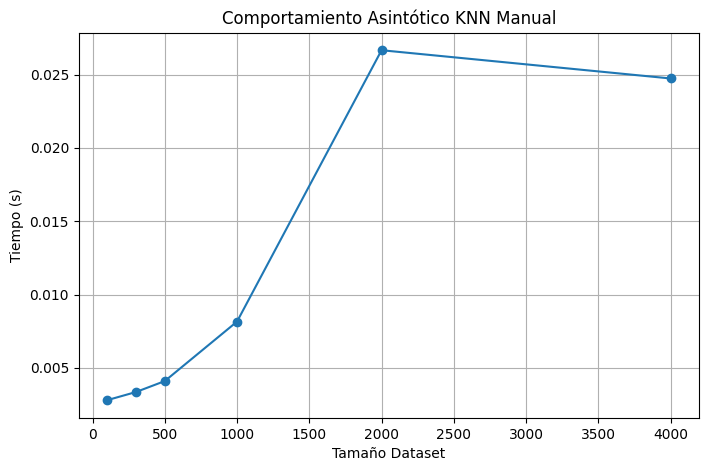

In [53]:
sizes = [
    100,
    300,
    500,
    1000,
    2000,
    4000
]

knn_manual_times = []

for size in sizes:

    subset = dataset[:size]

    start = time.time()

    scores = evaluate_algorithm(

        subset,
        k_nearest_neighbors,
        n_folds,
        num_neighbors

    )

    end = time.time()

    execution_time = (
        end - start
    )

    knn_manual_times.append(
    execution_time
    )

    print(

        f"Tamaño: {size} | "
        f"Tiempo: "
        f"{execution_time:.6f} segundos"

    )

plt.figure(figsize=(8,5))

plt.plot(

    sizes,
    times,
    marker='o'

)

plt.xlabel(
    "Tamaño Dataset"
)

plt.ylabel(
    "Tiempo (s)"
)

plt.title(
    "Comportamiento Asintótico KNN Manual"
)

plt.grid(True)

plt.show()

##Implementacion de KNN Sklearn

https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors

###La “optimización” aquí es solo acelerar la búsqueda, porque no aprender un modelo.
###KNeighborsClassifier de scikit-learn no optimiza parámetros durante el entrenamiento. En fit() almacena los datos y, dependiendo del parámetro algorithm='auto', puede usar brute force, KDTree o BallTree. La optimización principal ocurre en la búsqueda de vecinos durante predict().

In [54]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

In [55]:
X = rfm[[
    'Recency',
    'Frequency',
    'Monetary'
]]

y = rfm['target']

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

model = KNeighborsClassifier(

    n_neighbors=5,

    algorithm='auto'

)

model.fit(
    X_scaled,
    y
)

start = time.time()

y_pred = model.predict(
    X_scaled
)

end = time.time()

scores = cross_val_score(

    model,

    X_scaled,

    y,

    cv=5,

    scoring='accuracy'

)

print(
    "Scores:",
    scores
)

print(

    "Mean Accuracy: %.3f%%"
    % (scores.mean() * 100)

)

Scores: [0.94208494 0.95849421 0.93918919 0.96235521 0.93333333]
Mean Accuracy: 94.709%


##Medicion tiempo de prediccion

In [56]:
print(

    f"Tiempo KNN sklearn: "
    f"{end - start:.6f} segundos"

)

Tiempo KNN sklearn: 0.018291 segundos


##Medicion del tiempo asintotico sklearn

Tamaño: 100 | Tiempo predicción sklearn: 0.002824 segundos
Tamaño: 300 | Tiempo predicción sklearn: 0.003255 segundos
Tamaño: 500 | Tiempo predicción sklearn: 0.005419 segundos
Tamaño: 1000 | Tiempo predicción sklearn: 0.007532 segundos
Tamaño: 2000 | Tiempo predicción sklearn: 0.007265 segundos
Tamaño: 4000 | Tiempo predicción sklearn: 0.014173 segundos


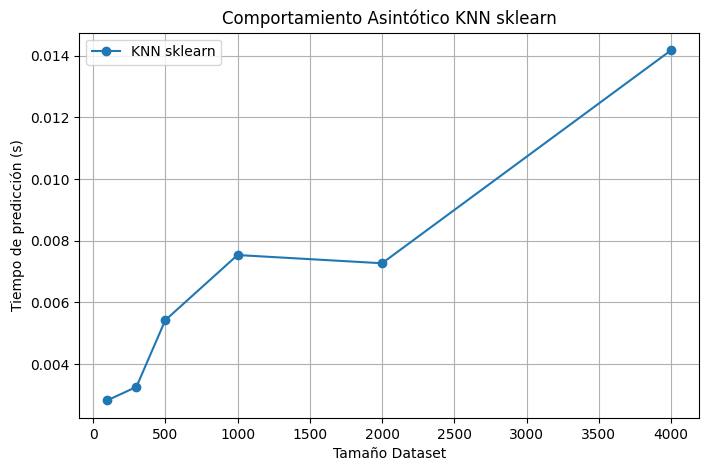

In [61]:
    sizes = [
    100,
    300,
    500,
    1000,
    2000,
    4000
]

knn_sklearn_times = []

for size in sizes:

    subset = rfm[:size]

    X_subset = subset[[
        'Recency',
        'Frequency',
        'Monetary'
    ]]

    y_subset = subset['target']

    scaler = MinMaxScaler()

    X_scaled_subset = scaler.fit_transform(
        X_subset
    )

    model = KNeighborsClassifier(
        n_neighbors=5,
        algorithm='auto'
    )

    model.fit(
        X_scaled_subset,
        y_subset
    )

    start = time.time()

    y_pred = model.predict(
        X_scaled_subset
    )

    end = time.time()

    execution_time = end - start

    knn_sklearn_times.append(
        execution_time
    )

    print(
        f"Tamaño: {size} | "
        f"Tiempo predicción sklearn: "
        f"{execution_time:.6f} segundos"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    knn_sklearn_times,
    marker='o',
    label='KNN sklearn'
)

plt.xlabel("Tamaño Dataset")

plt.ylabel(
    "Tiempo de predicción (s)"
)

plt.title(
    "Comportamiento Asintótico KNN sklearn"
)

plt.legend()

plt.grid(True)

plt.show()

##Comparacion

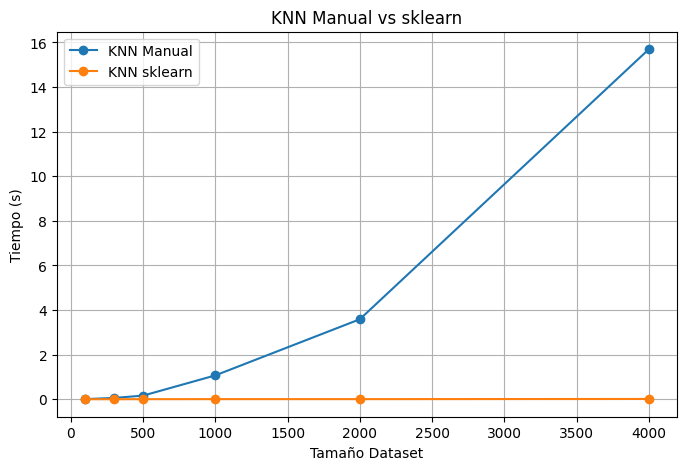

In [62]:
plt.figure(figsize=(8,5))

plt.plot(

    sizes,
    knn_manual_times,

    marker='o',

    label='KNN Manual'

)

plt.plot(

    sizes,
    knn_sklearn_times,

    marker='o',

    label='KNN sklearn'

)

plt.xlabel(
    "Tamaño Dataset"
)

plt.ylabel(
    "Tiempo (s)"
)

plt.title(
    "KNN Manual vs sklearn"
)

plt.legend()

plt.grid(True)

plt.show()

###Se observa que sklearn presenta menor tiempo de ejecución debido a que implementa estructuras de búsqueda optimizadas y rutinas compiladas, mientras que la versión manual calcula distancias usando ciclos explícitos en Python.

Referencia:
Scikit-learn. Nearest Neighbors.
https://scikit-learn.org/stable/modules/neighbors.html

Scikit-learn. KNeighborsClassifier.
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html